# Previsão de Performance e Bem-estar de Alunos

**Autores:** [Nome 1, Nº aluno] | [Nome 2, Nº aluno] | [Nome 3, Nº aluno] | **Grupo:** [Nº grupo]  
**Unidade Curricular:** Fundamentos de Aprendizagem Automática — 2024/2025  
**Data:** Abril 2026

---

## Introdução

O bem-estar e o desempenho académico dos alunos são influenciados por um conjunto complexo de fatores comportamentais e de estilo de vida. Com o aumento das exigências académicas, o burnout estudantil tornou-se uma preocupação crescente em instituições de ensino superior.

Este projeto aplica técnicas de **aprendizagem automática supervisionada** a um dataset de 5000 registos de alunos, com o objetivo de desenvolver modelos preditivos capazes de identificar alunos em risco e prever o seu desempenho académico com base em variáveis como hábitos de sono, tempo de estudo, uso de ecrãs, prática de exercício e saúde mental.

---

## Problema e Objetivos

Definimos duas tarefas preditivas complementares:

| Tarefa | Tipo | Target | Objetivo |
|--------|------|--------|----------|
| Prever nível de Burnout | **Classificação** | Baixo / Médio / Alto | Identificar alunos em risco de esgotamento |
| Prever Exam Score | **Regressão** | Nota contínua (0–100) | Estimar o desempenho académico esperado |

**Stakeholders:** Instituições de ensino, psicólogos escolares e os próprios alunos beneficiam destas previsões para intervir preventivamente e personalizar estratégias de apoio.

---

## Dataset

- **Dimensão:** 5000 registos × 21 features
- **Fonte:** `student_records_missing.csv` (contém valores em falta intencionais)
- **Tipos de variáveis:**
  - 11 numéricas contínuas (horas de estudo, sono, ecrã, exercício, etc.)
  - 2 nominais (`gender`, `academic_level`)
  - 1 ordinal (`internet_quality`)
  - 2 binárias (`part_time_job`, `upcoming_deadline`)
  - 4 targets (`focus_index`, `burnout_level`, `productivity_score`, `exam_score`)
  - 1 identificador (`student_id`, removido)

---

## Metodologia

```
Dataset → Pré-processamento → Divisão 80/20 → Feature Selection → Treino com CV → Avaliação no Test Set
```

1. **Pré-processamento:** pipeline com imputação (mediana), encoding por tipo de variável e StandardScaler
2. **Divisão:** 80% Learning Set (treino + validação) + 20% Test Set (avaliação final)
3. **Feature Selection:** comparação de 5 métodos (MI, F-Statistic, RF Importance, RFE, SFS)
4. **Modelos:** comparação de 6 modelos de classificação e 5 de regressão via cross-validation
5. **Avaliação:** métricas primária e secundária avaliadas no Test Set isolado

---

## Métricas de Avaliação

| Tarefa | Métrica Primária | Métrica Secundária |
|--------|-----------------|-------------------|
| Classificação (Burnout) | **F1-macro** — robusto a desequilíbrio entre classes | **Accuracy** — referência global |
| Regressão (Exam Score) | **MAE** — interpretável na unidade da nota | **R²** — proporção de variância explicada |

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_validate, train_test_split, KFold, StratifiedKFold
from sklearn.metrics import (mean_absolute_error, r2_score, accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix, classification_report)
from sklearn.feature_selection import (SelectKBest, f_classif, f_regression,
                                       mutual_info_classif, mutual_info_regression,
                                       RFE, SequentialFeatureSelector)

## 0. Carregar Dados e Preparar

Carregamos o dataset e definimos os tipos de cada feature:
- **Numéricas** (11): variáveis contínuas como horas de estudo, sono, ecrã — requerem imputação e escalonamento
- **Nominais** (2): `gender`, `academic_level` — sem ordem natural, codificadas com One-Hot (get_dummies)
- **Ordinal** (1): `internet_quality` — tem ordem (fraco < médio < bom), codificada com LabelEncoder
- **Binárias** (2): `part_time_job`, `upcoming_deadline` — já em formato 0/1

Removemos `student_id` (identificador sem valor preditivo) e todos os targets do espaço de features.

In [70]:
# Carregar o dataset
df = pd.read_csv('../Dados_Projeto/student_records_missing.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColunas do dataset:")
print(df.columns.tolist())

# Definir as features (componentes preditivas)
numeric_features = ['study_hours', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 
                     'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg', 'mental_health_score', 'age']
nominal_features = ['gender', 'academic_level']
ordinal_features = ['internet_quality']
binary_features = ['part_time_job', 'upcoming_deadline']

# Definir todos os targets (coisas que queremos prever)
all_targets = ['focus_index', 'burnout_level', 'productivity_score', 'exam_score']

# Remover todos os targets e student_id (que é apenas um ID)
X = df.drop(columns=all_targets + ['student_id'])

# Targets para cada tarefa
y_exam_score = df['exam_score']  # Regressão: prever a nota contínua
y_burnout_continuous = df['burnout_level']  # Será transformado em 3 classes

print(f"\nX shape: {X.shape}")
print(f"Features totais: {X.shape[1]}")
print(f"Exam Score (regressão): {y_exam_score.shape}")
print(f"Burnout Level (será classificação): {y_burnout_continuous.shape}")

Dataset shape: (5000, 21)

Colunas do dataset:
['student_id', 'age', 'gender', 'academic_level', 'study_hours', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline', 'internet_quality', 'mental_health_score', 'focus_index', 'burnout_level', 'productivity_score', 'exam_score']

X shape: (5000, 16)
Features totais: 16
Exam Score (regressão): (5000,)
Burnout Level (será classificação): (5000,)



Burnout Level - Quantis para 3 classes:
Quantil 1/3: 39.00
Quantil 2/3: 51.67

Distribuição das classes de Burnout:
0    1667
1    1666
2    1667
Name: count, dtype: int64
Percentagens: 0    33.3
1    33.3
2    33.3
Name: count, dtype: float64


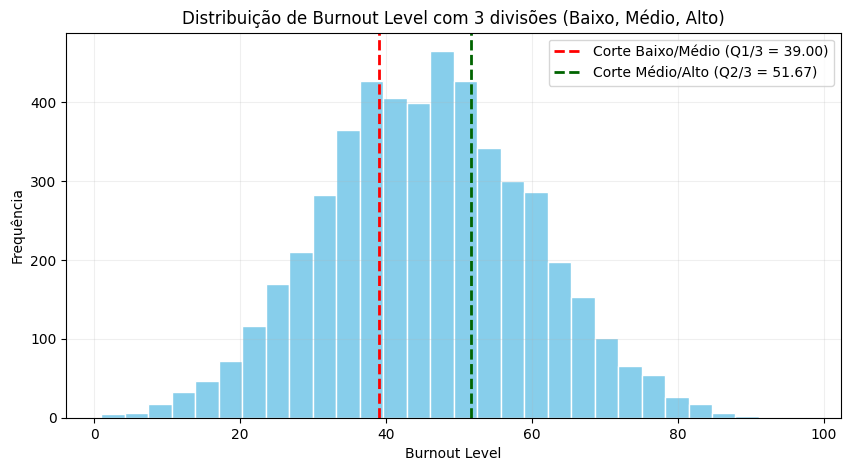

In [71]:
quantiles = y_burnout_continuous.quantile([1/3, 2/3])
q1 = quantiles.iloc[0]
q2 = quantiles.iloc[1]

print(f"\nBurnout Level - Quantis para 3 classes:")
print(f"Quantil 1/3: {q1:.2f}")
print(f"Quantil 2/3: {q2:.2f}")

y_burnout_class = pd.cut(
    y_burnout_continuous,
    bins=[y_burnout_continuous.min() - 1, q1, q2, y_burnout_continuous.max() + 1],
    labels=['Baixo', 'Médio', 'Alto'],
    include_lowest=True
)

y_burnout_class_encoded = pd.Categorical(y_burnout_class).codes

print(f"\nDistribuição das classes de Burnout:")
print(pd.Series(y_burnout_class_encoded).value_counts().sort_index())
print(f"Percentagens: {(pd.Series(y_burnout_class_encoded).value_counts().sort_index() / len(y_burnout_class_encoded) * 100).round(1)}")

plt.figure(figsize=(10, 5))
plt.hist(y_burnout_continuous, bins=30, color='skyblue', edgecolor='white')
plt.axvline(q1, color='red', linestyle='--', linewidth=2, label=f'Corte Baixo/Médio (Q1/3 = {q1:.2f})')
plt.axvline(q2, color='darkgreen', linestyle='--', linewidth=2, label=f'Corte Médio/Alto (Q2/3 = {q2:.2f})')
plt.title('Distribuição de Burnout Level com 3 divisões (Baixo, Médio, Alto)')
plt.xlabel('Burnout Level')
plt.ylabel('Frequência')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

---

# PRÉ-PROCESSAMENTO

## 0.5 Análise de Valores em Falta e Estratégias de Imputação

O dataset `student_records_missing.csv` contém valores em falta intencionais para simular dados reais.

**Estratégia:** Imputação pela **mediana** para todas as variáveis numéricas.
- A mediana é preferida à média porque é **robusta a outliers** — um aluno com valores extremos (ex: 0h de sono) não distorce a imputação dos restantes
- A imputação é ajustada apenas no **Learning Set** (`fit_transform`) e aplicada ao Test Set (`transform`), evitando data leakage

## 1. Divisão Learning Set e Test Set

Dividimos os dados em **80% Learning Set** e **20% Test Set** com `random_state=42` para reprodutibilidade.

- O **Learning Set** é usado exclusivamente para treino, validação cruzada e seleção de modelos
- O **Test Set** é guardado e só usado na avaliação final — simula dados novos nunca vistos pelo modelo
- Para classificação usamos `stratify=y` para garantir que a proporção de classes (Baixo/Médio/Alto) é preservada em ambos os conjuntos

In [72]:
# Divisão Learning Set (para model selection) e Test Set (para avaliação final)
# Nota: usar stratify para garantir distribuição equilibrada das classes

X_exam_learning, X_exam_test, y_exam_learning, y_exam_test = train_test_split(
    X, y_exam_score, test_size=0.2, random_state=42
)

X_burnout_learning, X_burnout_test, y_burnout_learning, y_burnout_test = train_test_split(
    X, y_burnout_class_encoded, test_size=0.2, random_state=42, stratify=y_burnout_class_encoded
)

print(f"Learning set shape: {X_exam_learning.shape}")
print(f"Test set shape: {X_exam_test.shape}")

print(f"\nDistribuição de classes no Learning Set:")
print(pd.Series(y_burnout_learning).value_counts().sort_index())

Learning set shape: (4000, 16)
Test set shape: (1000, 16)

Distribuição de classes no Learning Set:
0    1333
1    1333
2    1334
Name: count, dtype: int64


## 2. Construir o Pipeline de Pré-processamento

Construímos um pipeline que aplica transformações diferentes consoante o tipo de variável:

| Tipo | Variáveis | Transformação | Justificação |
|------|-----------|--------------|--------------|
| Nominal | `gender`, `academic_level` | **One-Hot (get_dummies)** | Sem ordem natural — One-Hot evita introduzir relações ordinais falsas |
| Ordinal | `internet_quality` | **LabelEncoder** | Tem ordem (fraco < médio < bom) — encoding ordinal preserva essa relação |
| Numérica + Binária | 11 + 2 variáveis | **Imputação mediana + StandardScaler** | Mediana robusta a outliers; StandardScaler normaliza a escala para modelos sensíveis a magnitude (SVM, KNN) |

O pipeline é ajustado **apenas no Learning Set** e aplicado ao Test Set para evitar data leakage.

In [73]:
# Pré-processamento: get_dummies (nominais) + LabelEncoding (ordinais) + Pipeline (numéricas)

# 1. Aplicar get_dummies às variáveis nominais 
print("PASSO 1: Aplicando get_dummies às nominais...")
X = pd.get_dummies(X, columns=nominal_features, drop_first=False)
X_learning = pd.get_dummies(X_exam_learning, columns=nominal_features, drop_first=False)
X_test = pd.get_dummies(X_exam_test, columns=nominal_features, drop_first=False)
X_learning_clf = pd.get_dummies(X_burnout_learning, columns=nominal_features, drop_first=False)
X_test_clf = pd.get_dummies(X_burnout_test, columns=nominal_features, drop_first=False)

# 2. LabelEncoding para variáveis ordinais 
print("\nPASSO 2: Aplicando LabelEncoding às ordinais...")
label_encoders = {}
for col in ordinal_features:
    le = LabelEncoder()
    # Fit no dataset completo
    X[col] = le.fit_transform(X[col].astype(str))
    # Transform nos splits
    X_learning[col] = le.transform(X_learning[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    X_learning_clf[col] = le.transform(X_learning_clf[col].astype(str))
    X_test_clf[col] = le.transform(X_test_clf[col].astype(str))
    label_encoders[col] = le

# 3. Pipeline para numéricas (impute + scale)
print("\nPASSO 3: Construindo pipeline para numéricas...")
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 4. ColumnTransformer para aplicar o pipeline às colunas numéricas e binárias
columns_to_process = numeric_features + binary_features
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, columns_to_process)
], remainder='passthrough')

print(f"✓ Pipeline construído para: {columns_to_process}")


PASSO 1: Aplicando get_dummies às nominais...

PASSO 2: Aplicando LabelEncoding às ordinais...

PASSO 3: Construindo pipeline para numéricas...
✓ Pipeline construído para: ['study_hours', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg', 'mental_health_score', 'age', 'part_time_job', 'upcoming_deadline']


In [74]:
print(f"  Shape: {X_learning.shape}")
print(f"  Colunas: {list(X_learning.columns)}\n")

# Aplicar o preprocessor (fit_transform no learning set)
X_learning_processed = preprocessor.fit_transform(X_learning)

# Obter nomes das colunas transformadas e converter para DataFrame
processed_feature_names = preprocessor.get_feature_names_out()
X_learning_processed_df = pd.DataFrame(
    X_learning_processed,
    columns=processed_feature_names,
    index=X_learning.index
)

print(f"\nPrimeiras 10 linhas do dataset processado:")
print(X_learning_processed_df.head(10))
print(f"\nShape após tratamento: {X_learning_processed_df.shape}")
print(f"Total de features finais: {X_learning_processed_df.shape[1]}")
print(f"\nColunas finais: {list(X_learning_processed_df.columns)}\n")

# Guardar em ficheiro CSV
csv_path = './X_learning_preprocessed.csv'
X_learning_processed_df.to_csv(csv_path)
print(f"✓ Ficheiro salvo em: {csv_path}")
print(f"✓ Dados: {X_learning_processed_df.shape[0]} linhas × {X_learning_processed_df.shape[1]} colunas")


  Shape: (4000, 20)
  Colunas: ['age', 'study_hours', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline', 'internet_quality', 'mental_health_score', 'gender_Female', 'gender_Male', 'gender_Other', 'academic_level_High School', 'academic_level_Postgraduate', 'academic_level_Undergraduate']


Primeiras 10 linhas do dataset processado:
     num__study_hours num__self_study_hours num__online_classes_hours  \
4227        -0.456773             -1.063374                  0.592132   
4676         0.944564             -1.446301                 -0.713774   
800          1.472126             -0.433671                   1.13879   
3671        -1.297575             -0.740013                 -0.308842   
4193        -0.791994              1.327794                 -0.875746   
2968        -1.594328              1.234189                 -1.928569   
4793    

---

# PARTE 1: CLASSIFICAÇÃO — Prever Nível de Burnout

O target `burnout_level` é uma variável contínua que dividimos em 3 classes equilibradas usando os quantis 1/3 e 2/3:
- **Baixo** (0): burnout_level abaixo do quantil 1/3
- **Médio** (1): entre quantil 1/3 e 2/3
- **Alto** (2): acima do quantil 2/3

Esta divisão garante classes aproximadamente balanceadas (~33% cada), o que é importante para a validade das métricas.

In [75]:

# Aplicar o preprocessor no learning set para classificação
X_burnout_learning_processed = preprocessor.fit_transform(X_learning_clf)
X_burnout_test_processed = preprocessor.transform(X_test_clf)

# Converter para DataFrame
X_burnout_learning_df = pd.DataFrame(
    X_burnout_learning_processed,
    columns=preprocessor.get_feature_names_out(),
    index=X_learning_clf.index
)

X_burnout_test_df = pd.DataFrame(
    X_burnout_test_processed,
    columns=preprocessor.get_feature_names_out(),
    index=X_test_clf.index
)

print(f"Learning set (classificação): {X_burnout_learning_df.shape}")
print(f"Test set (classificação): {X_burnout_test_df.shape}")
print(f"Target learning: {y_burnout_learning.shape}")
print(f"Target test: {y_burnout_test.shape}")


Learning set (classificação): (4000, 20)
Test set (classificação): (1000, 20)
Target learning: (4000,)
Target test: (1000,)


## 3. Baseline: Decision Tree com Validação Cruzada

A **Árvore de Decisão** é o modelo interpretável de referência para classificação — permite visualizar e explicar as decisões do modelo.

Testamos diferentes valores de `max_depth` via **5-fold Stratified Cross-Validation** no Learning Set para encontrar a profundidade que melhor generaliza, evitando:
- **Underfitting** (árvore demasiado rasa — não aprende os padrões)
- **Overfitting** (árvore demasiado profunda — memoriza o treino mas não generaliza)

**Métrica primária de seleção:** F1-macro (penaliza erros em todas as classes igualmente)

In [ ]:
# Baseline: Decision Tree com múltiplas profundidades via Cross-Validation (5-fold)
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

depths_clf = [2, 3, 4, 5, 6, 7, 8, 10, None]
cv_rows = []

for depth in depths_clf:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    pipe_clf = Pipeline(steps=[('model', model)])

    scores = cross_validate(
        pipe_clf,
        X_burnout_learning_df,
        y_burnout_learning,
        cv=skfold,
        scoring={
            'accuracy': 'accuracy',
            'precision': 'precision_macro',
            'recall': 'recall_macro',
            'f1': 'f1_macro',
            'roc_auc': 'roc_auc_ovr'
        },
        return_train_score=True
    )

    cv_rows.append({
        'max_depth': str(depth),
        'train_accuracy': scores['train_accuracy'].mean(),
        'val_accuracy': scores['test_accuracy'].mean(),
        'val_f1': scores['test_f1'].mean(),
        'val_auc': scores['test_roc_auc'].mean(),
        'std_accuracy': scores['test_accuracy'].std(),
    })

cv_df_clf = pd.DataFrame(cv_rows)
print("Resultados da Validação Cruzada - Decision Tree (5-fold):")
print(cv_df_clf.to_string(index=False))

# Melhor profundidade por F1 (métrica primária)
best_idx = cv_df_clf['val_f1'].idxmax()
best_depth_str = cv_df_clf.loc[best_idx, 'max_depth']
best_depth_clf = None if best_depth_str == 'None' else int(best_depth_str)

print(f"\n✓ Melhor max_depth: {best_depth_clf}")
print(f"  Val Accuracy: {cv_df_clf.loc[best_idx, 'val_accuracy']:.4f}")
print(f"  Val F1-macro: {cv_df_clf.loc[best_idx, 'val_f1']:.4f}")
print(f"  Val ROC-AUC:  {cv_df_clf.loc[best_idx, 'val_auc']:.4f}")

## 4. Feature Selection — 5 Métodos

Testamos 5 métodos diferentes para selecionar as features mais relevantes, todos aplicados ao Learning Set processado (top 12 features):

| Método | Como funciona |
|--------|--------------|
| **Mutual Information** | Mede dependência estatística entre cada feature e o target |
| **F-Statistic (ANOVA)** | Testa se a média da feature difere significativamente entre classes |
| **RF Importance** | Importância média de cada feature nas árvores do Random Forest |
| **RFE** | Remove iterativamente as features menos importantes do modelo |
| **SFS Forward** | Adiciona features uma a uma, escolhendo sempre a que mais melhora o modelo |

Aplicamos o fit **apenas no Learning Set** para evitar data leakage no Test Set.

In [ ]:
# MÉTODO 1: Mutual Information
print("=" * 80)
print("MÉTODO 1: MUTUAL INFORMATION")
print("=" * 80)

mi_scores = mutual_info_classif(X_burnout_learning_df, y_burnout_learning, random_state=42)
mi_ranking = pd.DataFrame({
    'feature': X_burnout_learning_df.columns,
    'score': mi_scores
}).sort_values('score', ascending=False)

print("\nTop 15 Features (Mutual Information):")
print(mi_ranking.head(15).to_string(index=False))

selector_mi = SelectKBest(mutual_info_classif, k=12)
X_burnout_learning_mi = selector_mi.fit_transform(X_burnout_learning_df, y_burnout_learning)
mi_cols = X_burnout_learning_df.columns[selector_mi.get_support()]
X_burnout_learning_mi_df = pd.DataFrame(X_burnout_learning_mi, columns=mi_cols, index=X_burnout_learning_df.index)
X_burnout_test_mi_df = pd.DataFrame(selector_mi.transform(X_burnout_test_df), columns=mi_cols, index=X_burnout_test_df.index)
print(f"\n✓ Features selecionadas (MI): {X_burnout_learning_mi_df.shape[1]}")

# MÉTODO 2: F-Statistic (ANOVA)
print("\n" + "=" * 80)
print("MÉTODO 2: F-STATISTIC (ANOVA)")
print("=" * 80)

f_scores = f_classif(X_burnout_learning_df, y_burnout_learning)[0]
f_ranking = pd.DataFrame({
    'feature': X_burnout_learning_df.columns,
    'score': f_scores
}).sort_values('score', ascending=False)

print("\nTop 15 Features (F-Statistic):")
print(f_ranking.head(15).to_string(index=False))

selector_f = SelectKBest(f_classif, k=12)
X_burnout_learning_f = selector_f.fit_transform(X_burnout_learning_df, y_burnout_learning)
f_cols = X_burnout_learning_df.columns[selector_f.get_support()]
X_burnout_learning_f_df = pd.DataFrame(X_burnout_learning_f, columns=f_cols, index=X_burnout_learning_df.index)
X_burnout_test_f_df = pd.DataFrame(selector_f.transform(X_burnout_test_df), columns=f_cols, index=X_burnout_test_df.index)
print(f"\n✓ Features selecionadas (F-Stat): {X_burnout_learning_f_df.shape[1]}")

# MÉTODO 3: Random Forest Feature Importance
print("\n" + "=" * 80)
print("MÉTODO 3: RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 80)

rf_temp = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_temp.fit(X_burnout_learning_df, y_burnout_learning)

rf_ranking = pd.DataFrame({
    'feature': X_burnout_learning_df.columns,
    'importance': rf_temp.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Features (RF Importance):")
print(rf_ranking.head(15).to_string(index=False))

top_12_rf = rf_ranking.head(12)['feature'].tolist()
X_burnout_learning_rf_df = X_burnout_learning_df[top_12_rf]
X_burnout_test_rf_df = X_burnout_test_df[top_12_rf]
print(f"\n✓ Features selecionadas (RF Importance): {X_burnout_learning_rf_df.shape[1]}")

# MÉTODO 4: Recursive Feature Elimination (RFE)
print("\n" + "=" * 80)
print("MÉTODO 4: RECURSIVE FEATURE ELIMINATION (RFE)")
print("=" * 80)

rfe = RFE(
    estimator=RandomForestClassifier(n_estimators=50, random_state=42, class_weight='balanced'),
    n_features_to_select=12,
    step=1
)
X_burnout_learning_rfe = rfe.fit_transform(X_burnout_learning_df, y_burnout_learning)
rfe_cols = X_burnout_learning_df.columns[rfe.support_]
X_burnout_learning_rfe_df = pd.DataFrame(X_burnout_learning_rfe, columns=rfe_cols, index=X_burnout_learning_df.index)
X_burnout_test_rfe_df = pd.DataFrame(rfe.transform(X_burnout_test_df), columns=rfe_cols, index=X_burnout_test_df.index)
print(f"\n✓ Features selecionadas (RFE): {X_burnout_learning_rfe_df.shape[1]}")
print(f"  Colunas: {list(rfe_cols)}")

# MÉTODO 5: Sequential Feature Selector (Forward)
print("\n" + "=" * 80)
print("MÉTODO 5: SEQUENTIAL FEATURE SELECTOR (Forward)")
print("=" * 80)

sfs_forward = SequentialFeatureSelector(
    estimator=RandomForestClassifier(n_estimators=50, random_state=42, class_weight='balanced'),
    n_features_to_select=12,
    direction='forward',
    cv=5
)
X_burnout_learning_sfs = sfs_forward.fit_transform(X_burnout_learning_df, y_burnout_learning)
sfs_cols = X_burnout_learning_df.columns[sfs_forward.get_support()]
X_burnout_learning_sfs_df = pd.DataFrame(X_burnout_learning_sfs, columns=sfs_cols, index=X_burnout_learning_df.index)
X_burnout_test_sfs_df = pd.DataFrame(sfs_forward.transform(X_burnout_test_df), columns=sfs_cols, index=X_burnout_test_df.index)
print(f"\n✓ Features selecionadas (SFS Forward): {X_burnout_learning_sfs_df.shape[1]}")

print("\n" + "=" * 80)
print("RESUMO: FEATURES SELECIONADAS POR MÉTODO")
print("=" * 80)
print(f"Dataset Original:       {X_burnout_learning_df.shape[1]} features")
print(f"Mutual Information:     {X_burnout_learning_mi_df.shape[1]} features")
print(f"F-Statistic:            {X_burnout_learning_f_df.shape[1]} features")
print(f"RF Importance:          {X_burnout_learning_rf_df.shape[1]} features")
print(f"RFE:                    {X_burnout_learning_rfe_df.shape[1]} features")
print(f"SFS Forward:            {X_burnout_learning_sfs_df.shape[1]} features")

## 5. Comparação: Modelos × Feature Selection Methods

Para encontrar a melhor combinação, testamos **todos os modelos com todos os métodos de FS** numa matriz completa.

Cada combinação é avaliada com **5-fold Cross-Validation no Learning Set** — o Test Set não é tocado nesta fase.
Os modelos testados foram selecionados por serem lecionados na UC:
- **Decision Tree** — modelo interpretável, baseline
- **Random Forest** — ensemble de árvores, robusto a overfitting
- **Logistic Regression** — modelo linear probabilístico
- **SVM (RBF)** — maximiza a margem de separação entre classes
- **KNN (k=5)** — classificação por vizinhança
- **Naive Bayes** — baseado em probabilidade condicional (Bayes)

In [ ]:
# Definir todos os modelos a comparar
models = {
    'Decision Tree':     DecisionTreeClassifier(max_depth=7, class_weight='balanced', random_state=42),
    'Random Forest':     RandomForestClassifier(n_estimators=100, max_depth=8, class_weight='balanced', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'SVM (RBF)':         SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
    'KNN (k=5)':         KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes':       GaussianNB(),
}

# Definir todos os conjuntos de features por método FS
feature_selection_methods = {
    'Sem FS (todas)': (X_burnout_learning_df,    X_burnout_test_df),
    'MI':             (X_burnout_learning_mi_df,  X_burnout_test_mi_df),
    'F-Statistic':    (X_burnout_learning_f_df,   X_burnout_test_f_df),
    'RF Importance':  (X_burnout_learning_rf_df,  X_burnout_test_rf_df),
    'RFE':            (X_burnout_learning_rfe_df, X_burnout_test_rfe_df),
    'SFS Forward':    (X_burnout_learning_sfs_df, X_burnout_test_sfs_df),
}

# Matriz de resultados
results_matrix = {}

print("=" * 130)
print("VALIDAÇÃO CRUZADA (5-fold): MODELOS × FEATURE SELECTION METHODS")
print("=" * 130)

for fs_name, (X_train_fs, _) in feature_selection_methods.items():
    print(f"\n{'='*130}")
    print(f"FEATURE SELECTION: {fs_name} ({X_train_fs.shape[1]} features)")
    print(f"{'='*130}")
    results_matrix[fs_name] = {}

    for model_name, model in models.items():
        pipe = Pipeline(steps=[('model', model)])
        scores = cross_validate(
            pipe,
            X_train_fs,
            y_burnout_learning,
            cv=skfold,
            scoring={'accuracy': 'accuracy', 'f1': 'f1_weighted',
                     'precision': 'precision_weighted', 'recall': 'recall_weighted'},
            return_train_score=False
        )
        acc  = scores['test_accuracy'].mean()
        std  = scores['test_accuracy'].std()
        f1   = scores['test_f1'].mean()

        results_matrix[fs_name][model_name] = {'accuracy': acc, 'accuracy_std': std, 'f1': f1}
        print(f"  {model_name:25} | Accuracy: {acc:.4f} ± {std:.4f} | F1: {f1:.4f}")

## 6. Análise dos Resultados — Tabela e Heatmaps

Apresentamos os resultados em:
1. **Matriz de Accuracy** — cada célula mostra a accuracy média (CV 5-fold) para um par (modelo × FS method)
2. **Top 10 combinações** — ordenadas por score ponderado (60% F1 + 40% Accuracy), dando prioridade à métrica primária
3. **Heatmaps** — visualização da performance para identificar padrões (quais modelos e FS methods são mais robustos)

In [ ]:
# Tabela resumo: melhor resultado por cada par (FS × Modelo)
print("=" * 150)
print("MATRIZ DE ACCURACY MÉDIA (Validação Cruzada)")
print("=" * 150)

accuracy_matrix_df = pd.DataFrame(
    {
        fs: {model: results_matrix[fs][model]['accuracy'] for model in models}
        for fs in feature_selection_methods
    }
)
print("\n" + accuracy_matrix_df.round(4).to_string())

# Top 10 combinações
best_combinations = []
for fs in feature_selection_methods:
    for model_name in models:
        acc = results_matrix[fs][model_name]['accuracy']
        f1  = results_matrix[fs][model_name]['f1']
        best_combinations.append({
            'FS Method': fs,
            'Model': model_name,
            'Accuracy': acc,
            'F1': f1,
            'Score': acc * 0.4 + f1 * 0.6   # F1 é métrica primária
        })

best_df = pd.DataFrame(best_combinations).sort_values('Score', ascending=False)

print("\n" + "=" * 150)
print("TOP 10 MELHORES COMBINAÇÕES (60% F1 + 40% Accuracy)")
print("=" * 150)
print("\n" + best_df.head(10)[['FS Method', 'Model', 'Accuracy', 'F1', 'Score']].to_string(index=False))

best_fs_method  = best_df.iloc[0]['FS Method']
best_model_name = best_df.iloc[0]['Model']
best_accuracy   = best_df.iloc[0]['Accuracy']
best_f1         = best_df.iloc[0]['F1']

print(f"\n>>> MELHOR COMBINAÇÃO: {best_model_name} + {best_fs_method}")
print(f"    Accuracy (CV): {best_accuracy:.4f}")
print(f"    F1-Score (CV): {best_f1:.4f}")

# Heatmap de Accuracy
plt.figure(figsize=(14, 6))
sns.heatmap(accuracy_matrix_df.T, annot=True, fmt='.3f', cmap='RdYlGn',
            cbar_kws={'label': 'Accuracy'})
plt.title('Accuracy por Combinação Modelo × Feature Selection Method (CV 5-fold)')
plt.xlabel('Modelo')
plt.ylabel('Feature Selection Method')
plt.tight_layout()
plt.show()

# Heatmap de F1
f1_matrix_df = pd.DataFrame(
    {
        fs: {model: results_matrix[fs][model]['f1'] for model in models}
        for fs in feature_selection_methods
    }
)

plt.figure(figsize=(14, 6))
sns.heatmap(f1_matrix_df.T, annot=True, fmt='.3f', cmap='RdYlGn',
            cbar_kws={'label': 'F1-Score'})
plt.title('F1-Score por Combinação Modelo × Feature Selection Method (CV 5-fold)')
plt.xlabel('Modelo')
plt.ylabel('Feature Selection Method')
plt.tight_layout()
plt.show()

## 7. Avaliação Final no Test Set

Com a **melhor combinação** (FS Method + Modelo) identificada pela CV, treinamos o modelo no **Learning Set completo** e avaliamos no **Test Set** — dados que nunca foram usados durante a seleção.

Este passo dá a estimativa mais realista de desempenho em dados novos. A comparação com o baseline (Decision Tree sem FS) quantifica o ganho obtido com a otimização.

In [ ]:
# Obter os dados do melhor método de FS
X_train_best, X_test_best = feature_selection_methods[best_fs_method]

# Retreinar o melhor modelo no Learning Set completo
best_model_final = models[best_model_name]
best_model_final.fit(X_train_best, y_burnout_learning)

y_burnout_pred_best = best_model_final.predict(X_test_best)

acc_best  = accuracy_score(y_burnout_test, y_burnout_pred_best)
prec_best = precision_score(y_burnout_test, y_burnout_pred_best, average='weighted', zero_division=0)
rec_best  = recall_score(y_burnout_test, y_burnout_pred_best, average='weighted', zero_division=0)
f1_best   = f1_score(y_burnout_test, y_burnout_pred_best, average='weighted', zero_division=0)

print("=" * 80)
print(f"AVALIAÇÃO FINAL NO TEST SET")
print(f"Modelo: {best_model_name} | FS: {best_fs_method}")
print("=" * 80)
print(f"  Accuracy:  {acc_best:.4f}")
print(f"  Precision: {prec_best:.4f}")
print(f"  Recall:    {rec_best:.4f}")
print(f"  F1-Score:  {f1_best:.4f}")

# Comparar com baseline (Decision Tree sem FS)
dt_baseline = DecisionTreeClassifier(max_depth=best_depth_clf, random_state=42)
dt_baseline.fit(X_burnout_learning_df, y_burnout_learning)
y_baseline_pred = dt_baseline.predict(X_burnout_test_df)
acc_baseline = accuracy_score(y_burnout_test, y_baseline_pred)
f1_baseline  = f1_score(y_burnout_test, y_baseline_pred, average='weighted', zero_division=0)

print("\n" + "=" * 80)
print("COMPARAÇÃO: BASELINE vs MELHOR MODELO")
print("=" * 80)
print(f"  Decision Tree baseline (sem FS): Accuracy={acc_baseline:.4f} | F1={f1_baseline:.4f}")
print(f"  {best_model_name} ({best_fs_method}):  Accuracy={acc_best:.4f} | F1={f1_best:.4f}")
print(f"  Melhoria Accuracy: {(acc_best - acc_baseline):+.4f} ({((acc_best - acc_baseline)/acc_baseline*100):+.1f}%)")
print(f"  Melhoria F1:       {(f1_best - f1_baseline):+.4f}")

# Matriz de confusão
cm = confusion_matrix(y_burnout_test, y_burnout_pred_best)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Baixo', 'Médio', 'Alto'],
            yticklabels=['Baixo', 'Médio', 'Alto'])
plt.title(f'Matriz de Confusão — {best_model_name} ({best_fs_method})')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.tight_layout()
plt.show()

print("\nRelatório de Classificação:")
print(classification_report(y_burnout_test, y_burnout_pred_best,
                            target_names=['Baixo', 'Médio', 'Alto'], zero_division=0))

---

# PARTE 2: REGRESSÃO — Prever Exam Score

## Métricas — Justificação

| Tarefa | Métrica Primária | Métrica Secundária |
|--------|-----------------|-------------------|
| Classificação (Burnout) | **F1-macro** — penaliza igualmente erros em todas as classes, robusto a desequilíbrio | **Accuracy** — fácil de interpretar, referência global |
| Regressão (Exam Score) | **MAE** — erro médio na mesma unidade que a nota, robusto a outliers | **R²** — proporção de variância explicada pelo modelo |

## 1. Pré-processamento para Regressão

O preprocessor é refitted no Learning Set de regressão (`X_learning`) — o split de regressão usa `y_exam_score` como target, distinto do split de classificação.

Aplicamos o mesmo pipeline: imputação mediana + StandardScaler nas numéricas, One-Hot nas nominais, LabelEncoder na ordinal.

In [ ]:
# Refit do preprocessor no learning set de regressão
X_reg_learning_processed = preprocessor.fit_transform(X_learning)
X_reg_test_processed = preprocessor.transform(X_test)

feature_names_reg = preprocessor.get_feature_names_out()

X_reg_learning_df = pd.DataFrame(X_reg_learning_processed, columns=feature_names_reg, index=X_learning.index)
X_reg_test_df     = pd.DataFrame(X_reg_test_processed,     columns=feature_names_reg, index=X_test.index)

print(f"Learning set (regressão): {X_reg_learning_df.shape}")
print(f"Test set (regressão):     {X_reg_test_df.shape}")
print(f"Target learning: {y_exam_learning.shape}")
print(f"Target test:     {y_exam_test.shape}")

## 2. Baseline: Linear Regression + Decision Tree Regressor com CV

Estabelecemos dois modelos interpretáveis como baseline para regressão:
- **Linear Regression** — assume relação linear entre features e target; coeficientes diretamente interpretáveis
- **Decision Tree Regressor** — divide o espaço de features em regiões com valor médio constante; interpretável mas propenso a overfitting

Avaliação com **5-fold CV** usando as métricas primária (MAE) e secundária (R²).

In [ ]:
# Baseline de regressão com 5-fold CV
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

baselines_reg = {
    'Linear Regression':    LinearRegression(),
    'Decision Tree Reg':    DecisionTreeRegressor(random_state=42),
}

print("=" * 80)
print("BASELINE REGRESSÃO — Validação Cruzada (5-fold)")
print("=" * 80)

baseline_reg_results = {}
for name, model in baselines_reg.items():
    pipe = Pipeline(steps=[('model', model)])
    scores = cross_validate(pipe, X_reg_learning_df, y_exam_learning, cv=kfold,
                            scoring=['neg_mean_absolute_error', 'r2'],
                            return_train_score=True)
    mae = -scores['test_neg_mean_absolute_error'].mean()
    r2  =  scores['test_r2'].mean()
    baseline_reg_results[name] = {'MAE': mae, 'R2': r2}
    print(f"  {name:25} | MAE: {mae:.4f} | R²: {r2:.4f}")

## 3. Feature Selection para Regressão — 5 Métodos

Aplicamos os mesmos 5 métodos de seleção, mas com versões adaptadas a regressão:
- `mutual_info_regression` em vez de `mutual_info_classif`
- `f_regression` em vez de `f_classif`
- `RandomForestRegressor` para RF Importance e RFE

Todos selecionam as **top 12 features** do Learning Set de regressão.

In [ ]:
# MÉTODO 1: Mutual Information (regressão)
print("=" * 80)
print("MÉTODO 1: MUTUAL INFORMATION")
print("=" * 80)

mi_reg_scores = mutual_info_regression(X_reg_learning_df, y_exam_learning, random_state=42)
mi_reg_ranking = pd.DataFrame({'feature': X_reg_learning_df.columns, 'score': mi_reg_scores}).sort_values('score', ascending=False)
print("\nTop 15 Features (MI Regressão):")
print(mi_reg_ranking.head(15).to_string(index=False))

selector_mi_reg = SelectKBest(mutual_info_regression, k=12)
X_reg_learning_mi = selector_mi_reg.fit_transform(X_reg_learning_df, y_exam_learning)
mi_reg_cols = X_reg_learning_df.columns[selector_mi_reg.get_support()]
X_reg_learning_mi_df = pd.DataFrame(X_reg_learning_mi, columns=mi_reg_cols, index=X_reg_learning_df.index)
X_reg_test_mi_df     = pd.DataFrame(selector_mi_reg.transform(X_reg_test_df), columns=mi_reg_cols, index=X_reg_test_df.index)
print(f"\n✓ Features selecionadas (MI): {X_reg_learning_mi_df.shape[1]}")

# MÉTODO 2: F-Statistic
print("\n" + "=" * 80)
print("MÉTODO 2: F-STATISTIC")
print("=" * 80)

selector_f_reg = SelectKBest(f_regression, k=12)
X_reg_learning_f = selector_f_reg.fit_transform(X_reg_learning_df, y_exam_learning)
f_reg_cols = X_reg_learning_df.columns[selector_f_reg.get_support()]
X_reg_learning_f_df = pd.DataFrame(X_reg_learning_f, columns=f_reg_cols, index=X_reg_learning_df.index)
X_reg_test_f_df     = pd.DataFrame(selector_f_reg.transform(X_reg_test_df), columns=f_reg_cols, index=X_reg_test_df.index)
print(f"✓ Features selecionadas (F-Stat): {X_reg_learning_f_df.shape[1]}")
print(f"  Colunas: {list(f_reg_cols)}")

# MÉTODO 3: RF Importance
print("\n" + "=" * 80)
print("MÉTODO 3: RANDOM FOREST IMPORTANCE")
print("=" * 80)

rf_reg_temp = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg_temp.fit(X_reg_learning_df, y_exam_learning)
rf_reg_ranking = pd.DataFrame({'feature': X_reg_learning_df.columns, 'importance': rf_reg_temp.feature_importances_}).sort_values('importance', ascending=False)
print("\nTop 15 Features (RF Regressão):")
print(rf_reg_ranking.head(15).to_string(index=False))

top12_rf_reg = rf_reg_ranking.head(12)['feature'].tolist()
X_reg_learning_rf_df = X_reg_learning_df[top12_rf_reg]
X_reg_test_rf_df     = X_reg_test_df[top12_rf_reg]
print(f"\n✓ Features selecionadas (RF): {X_reg_learning_rf_df.shape[1]}")

# MÉTODO 4: RFE
print("\n" + "=" * 80)
print("MÉTODO 4: RFE")
print("=" * 80)

rfe_reg = RFE(estimator=RandomForestRegressor(n_estimators=50, random_state=42), n_features_to_select=12, step=1)
X_reg_learning_rfe = rfe_reg.fit_transform(X_reg_learning_df, y_exam_learning)
rfe_reg_cols = X_reg_learning_df.columns[rfe_reg.support_]
X_reg_learning_rfe_df = pd.DataFrame(X_reg_learning_rfe, columns=rfe_reg_cols, index=X_reg_learning_df.index)
X_reg_test_rfe_df     = pd.DataFrame(rfe_reg.transform(X_reg_test_df), columns=rfe_reg_cols, index=X_reg_test_df.index)
print(f"✓ Features selecionadas (RFE): {X_reg_learning_rfe_df.shape[1]}")
print(f"  Colunas: {list(rfe_reg_cols)}")

# MÉTODO 5: SFS Forward
print("\n" + "=" * 80)
print("MÉTODO 5: SEQUENTIAL FEATURE SELECTOR (Forward)")
print("=" * 80)

sfs_reg = SequentialFeatureSelector(estimator=RandomForestRegressor(n_estimators=50, random_state=42),
                                    n_features_to_select=12, direction='forward', cv=5)
X_reg_learning_sfs = sfs_reg.fit_transform(X_reg_learning_df, y_exam_learning)
sfs_reg_cols = X_reg_learning_df.columns[sfs_reg.get_support()]
X_reg_learning_sfs_df = pd.DataFrame(X_reg_learning_sfs, columns=sfs_reg_cols, index=X_reg_learning_df.index)
X_reg_test_sfs_df     = pd.DataFrame(sfs_reg.transform(X_reg_test_df), columns=sfs_reg_cols, index=X_reg_test_df.index)
print(f"✓ Features selecionadas (SFS): {X_reg_learning_sfs_df.shape[1]}")

## 4. Comparação: Modelos × Feature Selection (Regressão)

Mesma abordagem da classificação — matriz completa de modelos × métodos de FS com CV 5-fold.

Modelos de regressão testados (lecionados na UC):
- **Linear Regression** — baseline interpretável
- **Decision Tree Regressor** — não-linear, interpretável
- **Random Forest Regressor** — ensemble, robusto
- **KNN Regressor** — baseado em vizinhança
- **SVR (RBF)** — maximiza margem em espaço de features transformado

In [ ]:
# Modelos de regressão a comparar
models_reg = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Reg': DecisionTreeRegressor(max_depth=7, random_state=42),
    'Random Forest Reg': RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42),
    'KNN Reg (k=5)':     KNeighborsRegressor(n_neighbors=5),
    'SVR (RBF)':         SVR(kernel='rbf'),
}

feature_selection_methods_reg = {
    'Sem FS (todas)': (X_reg_learning_df,    X_reg_test_df),
    'MI':             (X_reg_learning_mi_df,  X_reg_test_mi_df),
    'F-Statistic':    (X_reg_learning_f_df,   X_reg_test_f_df),
    'RF Importance':  (X_reg_learning_rf_df,  X_reg_test_rf_df),
    'RFE':            (X_reg_learning_rfe_df, X_reg_test_rfe_df),
    'SFS Forward':    (X_reg_learning_sfs_df, X_reg_test_sfs_df),
}

results_matrix_reg = {}

print("=" * 130)
print("VALIDAÇÃO CRUZADA (5-fold): MODELOS × FEATURE SELECTION METHODS — REGRESSÃO")
print("=" * 130)

for fs_name, (X_train_fs, _) in feature_selection_methods_reg.items():
    print(f"\n{'='*130}")
    print(f"FEATURE SELECTION: {fs_name} ({X_train_fs.shape[1]} features)")
    print(f"{'='*130}")
    results_matrix_reg[fs_name] = {}

    for model_name, model in models_reg.items():
        pipe = Pipeline(steps=[('model', model)])
        scores = cross_validate(pipe, X_train_fs, y_exam_learning, cv=kfold,
                                scoring=['neg_mean_absolute_error', 'r2'],
                                return_train_score=False)
        mae = -scores['test_neg_mean_absolute_error'].mean()
        r2  =  scores['test_r2'].mean()
        results_matrix_reg[fs_name][model_name] = {'MAE': mae, 'R2': r2}
        print(f"  {model_name:25} | MAE: {mae:.4f} | R²: {r2:.4f}")

## 5. Análise dos Resultados — Regressão

Ordenamos por **MAE crescente** (menor MAE = melhor), que é a métrica primária.
O heatmap permite visualizar quais combinações de modelo × FS method produzem menores erros absolutos de previsão.

In [ ]:
# Tabela resumo regressão
print("=" * 120)
print("RESUMO: MAE por Modelo × Feature Selection Method (CV 5-fold)")
print("=" * 120)

mae_matrix_reg = pd.DataFrame(
    {fs: {model: results_matrix_reg[fs][model]['MAE'] for model in models_reg}
     for fs in feature_selection_methods_reg}
)
print("\n" + mae_matrix_reg.round(4).to_string())

# Top 10 combinações (menor MAE = melhor)
best_reg_combinations = []
for fs in feature_selection_methods_reg:
    for model_name in models_reg:
        mae = results_matrix_reg[fs][model_name]['MAE']
        r2  = results_matrix_reg[fs][model_name]['R2']
        best_reg_combinations.append({'FS Method': fs, 'Model': model_name, 'MAE': mae, 'R2': r2})

best_reg_df = pd.DataFrame(best_reg_combinations).sort_values('MAE')

print("\n" + "=" * 120)
print("TOP 10 MELHORES COMBINAÇÕES (menor MAE)")
print("=" * 120)
print("\n" + best_reg_df.head(10)[['FS Method', 'Model', 'MAE', 'R2']].to_string(index=False))

best_fs_reg   = best_reg_df.iloc[0]['FS Method']
best_model_reg = best_reg_df.iloc[0]['Model']
best_mae_reg  = best_reg_df.iloc[0]['MAE']
best_r2_reg   = best_reg_df.iloc[0]['R2']

print(f"\n>>> MELHOR COMBINAÇÃO: {best_model_reg} + {best_fs_reg}")
print(f"    MAE (CV): {best_mae_reg:.4f}")
print(f"    R²  (CV): {best_r2_reg:.4f}")

# Heatmap MAE
plt.figure(figsize=(14, 5))
sns.heatmap(mae_matrix_reg.T, annot=True, fmt='.3f', cmap='RdYlGn_r', cbar_kws={'label': 'MAE'})
plt.title('MAE por Combinação Modelo × Feature Selection Method (CV 5-fold)')
plt.xlabel('Modelo')
plt.ylabel('Feature Selection Method')
plt.tight_layout()
plt.show()

## 6. Avaliação Final no Test Set — Regressão

Treinamos a melhor combinação no Learning Set completo e avaliamos no Test Set.
O gráfico **Real vs Previsto** mostra visualmente a qualidade das previsões — pontos próximos da diagonal vermelha indicam previsões mais precisas.

In [ ]:
# Avaliação final no Test Set
X_train_best_reg, X_test_best_reg = feature_selection_methods_reg[best_fs_reg]

best_model_reg_final = models_reg[best_model_reg]
best_model_reg_final.fit(X_train_best_reg, y_exam_learning)
y_exam_pred_best = best_model_reg_final.predict(X_test_best_reg)

mae_best_reg  = mean_absolute_error(y_exam_test, y_exam_pred_best)
r2_best_reg   = r2_score(y_exam_test, y_exam_pred_best)
rmse_best_reg = np.sqrt(np.mean((y_exam_test - y_exam_pred_best)**2))

# Baseline Linear Regression (sem FS)
lr_baseline = LinearRegression()
lr_baseline.fit(X_reg_learning_df, y_exam_learning)
y_exam_pred_baseline = lr_baseline.predict(X_reg_test_df)
mae_baseline_reg = mean_absolute_error(y_exam_test, y_exam_pred_baseline)
r2_baseline_reg  = r2_score(y_exam_test, y_exam_pred_baseline)

print("=" * 80)
print("AVALIAÇÃO FINAL NO TEST SET — REGRESSÃO")
print("=" * 80)
print(f"  Modelo: {best_model_reg} | FS: {best_fs_reg}")
print(f"  MAE:  {mae_best_reg:.4f}")
print(f"  RMSE: {rmse_best_reg:.4f}")
print(f"  R²:   {r2_best_reg:.4f}")

print("\n" + "=" * 80)
print("COMPARAÇÃO: BASELINE vs MELHOR MODELO")
print("=" * 80)
print(f"  Linear Regression (baseline): MAE={mae_baseline_reg:.4f} | R²={r2_baseline_reg:.4f}")
print(f"  {best_model_reg} ({best_fs_reg}): MAE={mae_best_reg:.4f} | R²={r2_best_reg:.4f}")
print(f"  Melhoria MAE: {(mae_baseline_reg - mae_best_reg):+.4f}")

# Gráfico: Real vs Previsto
plt.figure(figsize=(8, 6))
plt.scatter(y_exam_test, y_exam_pred_best, alpha=0.4, color='steelblue', s=15)
plt.plot([y_exam_test.min(), y_exam_test.max()],
         [y_exam_test.min(), y_exam_test.max()], 'r--', linewidth=2, label='Previsão perfeita')
plt.xlabel('Exam Score Real')
plt.ylabel('Exam Score Previsto')
plt.title(f'Real vs Previsto — {best_model_reg} ({best_fs_reg})')
plt.legend()
plt.tight_layout()
plt.show()

---

# ANÁLISE DE ERRO

Inspecionamos os casos onde os modelos erraram mais para identificar padrões e potenciais causas.

**Classificação:** analisamos quais classes têm mais erros e se os exemplos mal classificados têm características distintivas.

**Regressão:** identificamos os outliers de previsão (maiores erros absolutos) e analisamos se correspondem a valores extremos do target.

In [ ]:
# ── ANÁLISE DE ERRO: CLASSIFICAÇÃO (Burnout) ──────────────────────────────

X_train_clf_best, X_test_clf_best = feature_selection_methods[best_fs_method]
best_clf_for_error = models[best_model_name]
best_clf_for_error.fit(X_train_clf_best, y_burnout_learning)
y_clf_pred_error = best_clf_for_error.predict(X_test_clf_best)

# Erros de classificação: casos mal classificados
clf_error_df = X_burnout_test_df.copy()
clf_error_df['y_real']    = np.array(y_burnout_test)
clf_error_df['y_pred']    = y_clf_pred_error
clf_error_df['erro']      = clf_error_df['y_real'] != clf_error_df['y_pred']

erros_clf = clf_error_df[clf_error_df['erro']]
print("=" * 80)
print(f"ANÁLISE DE ERRO — CLASSIFICAÇÃO ({best_model_name} + {best_fs_method})")
print("=" * 80)
print(f"Total de erros: {len(erros_clf)} / {len(clf_error_df)} ({len(erros_clf)/len(clf_error_df)*100:.1f}%)")
print(f"\nDistribuição dos erros por classe real:")
print(erros_clf['y_real'].value_counts().rename({0:'Baixo', 1:'Médio', 2:'Alto'}))
print(f"\nDistribuição dos erros por classe prevista:")
print(erros_clf['y_pred'].value_counts().rename({0:'Baixo', 1:'Médio', 2:'Alto'}))

# Comparar médias das features: erros vs acertos
print(f"\nMédias das features mais relevantes (Erros vs Acertos):")
top_features_clf = ['num__sleep_hours', 'num__upcoming_deadline', 'num__screen_time_hours']
existing = [f for f in top_features_clf if f in clf_error_df.columns]
if existing:
    comp = pd.DataFrame({
        'Erros':   erros_clf[existing].mean(),
        'Acertos': clf_error_df[~clf_error_df['erro']][existing].mean()
    })
    print(comp.round(4))

# ── ANÁLISE DE ERRO: REGRESSÃO (Exam Score) ───────────────────────────────

reg_error_df = X_reg_test_df.copy()
reg_error_df['y_real']    = np.array(y_exam_test)
reg_error_df['y_pred']    = y_exam_pred_best
reg_error_df['erro_abs']  = np.abs(reg_error_df['y_real'] - reg_error_df['y_pred'])
reg_error_df['erro_rel']  = reg_error_df['erro_abs'] / reg_error_df['y_real']

# Outliers: top 10 maiores erros absolutos
top_erros_reg = reg_error_df.nlargest(10, 'erro_abs')[['y_real', 'y_pred', 'erro_abs']]

print("\n" + "=" * 80)
print(f"ANÁLISE DE ERRO — REGRESSÃO ({best_model_reg} + {best_fs_reg})")
print("=" * 80)
print(f"MAE geral: {reg_error_df['erro_abs'].mean():.4f}")
print(f"Erro máximo: {reg_error_df['erro_abs'].max():.4f}")
print(f"Casos com erro > 10 pontos: {(reg_error_df['erro_abs'] > 10).sum()}")
print(f"\nTop 10 maiores erros:")
print(top_erros_reg.to_string(index=False))

# Distribuição dos erros
plt.figure(figsize=(10, 4))
plt.hist(reg_error_df['erro_abs'], bins=40, color='salmon', edgecolor='white')
plt.axvline(reg_error_df['erro_abs'].mean(), color='red', linestyle='--', label=f'MAE = {reg_error_df["erro_abs"].mean():.2f}')
plt.xlabel('Erro Absoluto (pontos)')
plt.ylabel('Frequência')
plt.title('Distribuição do Erro Absoluto — Regressão (Exam Score)')
plt.legend()
plt.tight_layout()
plt.show()